<a href="https://colab.research.google.com/github/BAravind-5/Task_12/blob/main/Task12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("prateekiet/mall-costumers")

print("Path to dataset files:", path)

100%|██████████| 1.55k/1.55k [00:00<00:00, 2.17MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prateekiet/mall-costumers/versions/1


In [4]:
import pandas as pd
import os

# The 'path' variable from the previous cell (zItDVVxheBnh) holds the directory where the dataset was downloaded.
# It is: '/root/.cache/kagglehub/datasets/prateekiet/mall-costumers/versions/1'

# List the contents of the directory to find the actual CSV file
file_names = os.listdir(path)
csv_file = None
for file_name in file_names:
    if file_name.endswith('.csv'):
        csv_file = file_name
        break

if csv_file:
    full_csv_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_csv_path)
    print(df.head())
else:
    print("No CSV file found in the downloaded directory.")

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Annual Income and Spending Score are key features for customer segmentation.

In [6]:
df = df.drop('CustomerID', axis=1)

In [7]:
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling is required because KMeans uses distance calculations.

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

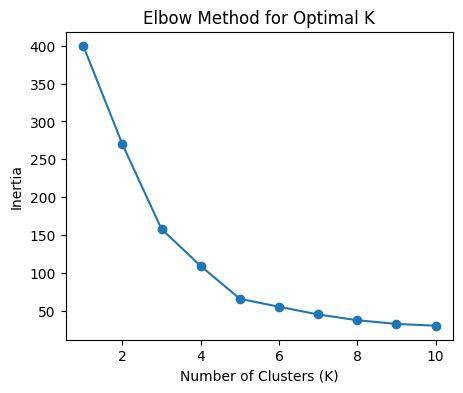

In [9]:
plt.figure(figsize=(5,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

The elbow point indicates the optimal number of clusters where inertia
starts decreasing more slowly.

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


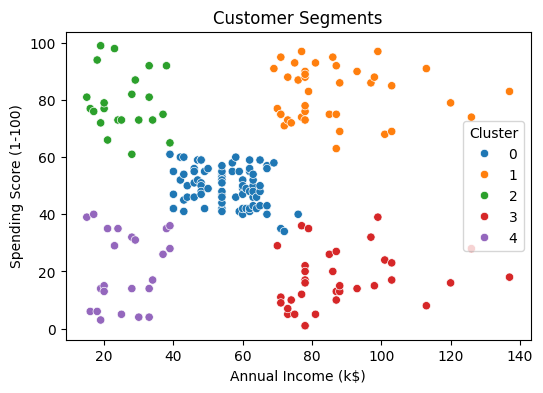

In [11]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='tab10'
)
plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

Cluster Interpretation:

Cluster 0: Low income, low spending – Budget customers
Cluster 1: High income, low spending – Conservative customers
Cluster 2: Low income, high spending – Carefree spenders
Cluster 3: High income, high spending – Premium customers
Cluster 4: Medium income, medium spending – Average customers